In [1]:
#* データ処理・グラフ作成・機械学習に必要なライブラリを読み込む
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             precision_score, recall_score, f1_score)

#* グラフの表示形式と、結果を再現するための乱数を設定する
sns.set_theme(style='whitegrid', rc={
    'figure.figsize': (8, 6),
    'font.size': 11
})
RANDOM_STATE = 42

#* モデル構築とチューニングに使用する設定値を指定する
k_in_knn = 5
max_number_of_k = 20
fold_number = 5
number_of_test_samples = 154
rf_number_of_trees = 300
rf_x_variables_rates = np.arange(1, 11, dtype=float) / 10


In [2]:
#* 糖尿病データを読み込み、データ数・欠損値・クラス数を確認する
dataset = pd.read_csv('diabetes.csv')
display(dataset.head())
print(f'データ数: {dataset.shape[0]}、列数: {dataset.shape[1]}')
print(f'欠損値の合計: {dataset.isnull().sum().sum()}')
display(dataset['Outcome'].value_counts().sort_index().rename('件数').to_frame())

#* Outcomeを目的変数、その他の8列を説明変数に分ける
y = dataset['Outcome']
x = dataset.drop(columns=['Outcome'])

#* クラス比率を保ったまま、トレーニングデータとテストデータに分割する
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=number_of_test_samples,
    shuffle=True,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'目的変数: Outcome')
print(f'説明変数の数: {x.shape[1]}')
print(f'トレーニングデータ: {x_train.shape[0]}件')
print(f'テストデータ: {x_test.shape[0]}件')


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


データ数: 768、列数: 9
欠損値の合計: 0


,件数
Outcome,
0,500
1,268


目的変数: Outcome
説明変数の数: 8
トレーニングデータ: 614件
テストデータ: 154件


In [3]:
#* 学習済みモデルから予測値を取得し、評価指標と混同行列を表示する関数を定義する
def evaluate_model(model, evaluation_x, evaluation_y, model_name):
    #* テストデータのクラスと、糖尿病クラス1になる予測確率を求める
    predicted_class = model.predict(evaluation_x)
    predicted_probability = model.predict_proba(evaluation_x)[:, 1]

    #* Accuracy・Precision・Recall・F1を計算する
    scores = {
        'Model': model_name,
        'Accuracy': accuracy_score(evaluation_y, predicted_class),
        'Precision': precision_score(evaluation_y, predicted_class, zero_division=0),
        'Recall': recall_score(evaluation_y, predicted_class, zero_division=0),
        'F1': f1_score(evaluation_y, predicted_class, zero_division=0)
    }

    print(f'【{model_name}】')
    print(f"Accuracy : {scores['Accuracy']:.4f}")
    print(f"Precision: {scores['Precision']:.4f}")
    print(f"Recall   : {scores['Recall']:.4f}")
    print(f"F1       : {scores['F1']:.4f}")

    #* 実際のクラスと予測クラスを比較する混同行列を表示する
    confusion_matrix_display = ConfusionMatrixDisplay.from_predictions(
        evaluation_y,
        predicted_class,
        display_labels=['No diabetes (0)', 'Diabetes (1)'],
        cmap='Blues',
        colorbar=False
    )
    #* 混同行列の数字を大きくし、数字に重なるグリッド線を消す
    confusion_matrix_display.ax_.grid(False)
    for text in confusion_matrix_display.text_.ravel():
        text.set_fontsize(24)
        text.set_fontweight('bold')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.tight_layout()
    plt.show()

    return scores, predicted_class, predicted_probability


【kNN Default】
Accuracy : 0.7013
Precision: 0.5833
Recall   : 0.5185
F1       : 0.5490


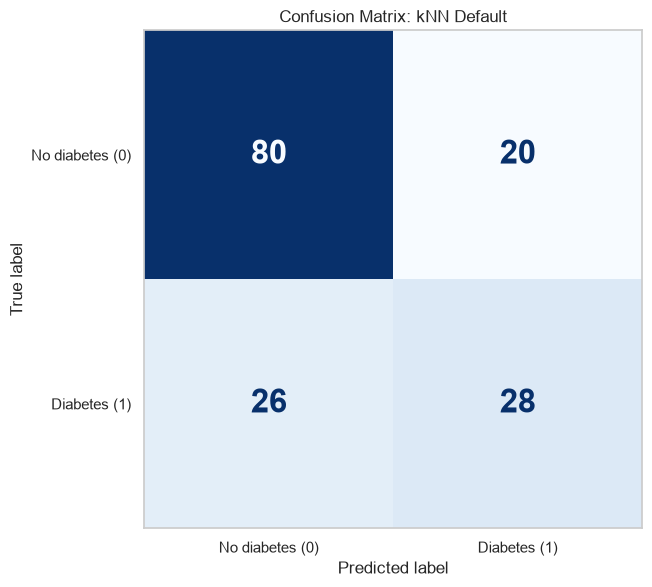

In [4]:
#* kNNで距離を公平に計算するため、トレーニングデータの平均と標準偏差で標準化する
autoscaled_x_train = (x_train - x_train.mean()) / x_train.std()
autoscaled_x_test = (x_test - x_train.mean()) / x_train.std()

#* k=5、ユークリッド距離のデフォルトkNNモデルを構築する
knn_default = KNeighborsClassifier(n_neighbors=k_in_knn, metric='euclidean')
knn_default.fit(autoscaled_x_train, y_train)

#* デフォルトkNNモデルをテストデータで評価する
knn_default_scores, knn_default_pred, knn_default_prob = evaluate_model(
    knn_default, autoscaled_x_test, y_test, 'kNN Default'
)


k =  1, CV Accuracy = 0.7134
k =  2, CV Accuracy = 0.6987
k =  3, CV Accuracy = 0.7182
k =  4, CV Accuracy = 0.7166
k =  5, CV Accuracy = 0.7329
k =  6, CV Accuracy = 0.7296


k =  7, CV Accuracy = 0.7508
k =  8, CV Accuracy = 0.7508


k =  9, CV Accuracy = 0.7541


k = 10, CV Accuracy = 0.7492
k = 11, CV Accuracy = 0.7492
k = 12, CV Accuracy = 0.7573
k = 13, CV Accuracy = 0.7590
k = 14, CV Accuracy = 0.7557
k = 15, CV Accuracy = 0.7476
k = 16, CV Accuracy = 0.7427
k = 17, CV Accuracy = 0.7410
k = 18, CV Accuracy = 0.7492
k = 19, CV Accuracy = 0.7443


k = 20, CV Accuracy = 0.7476
交差検証で選択されたk: 13
交差検証の最良Accuracy: 0.7590


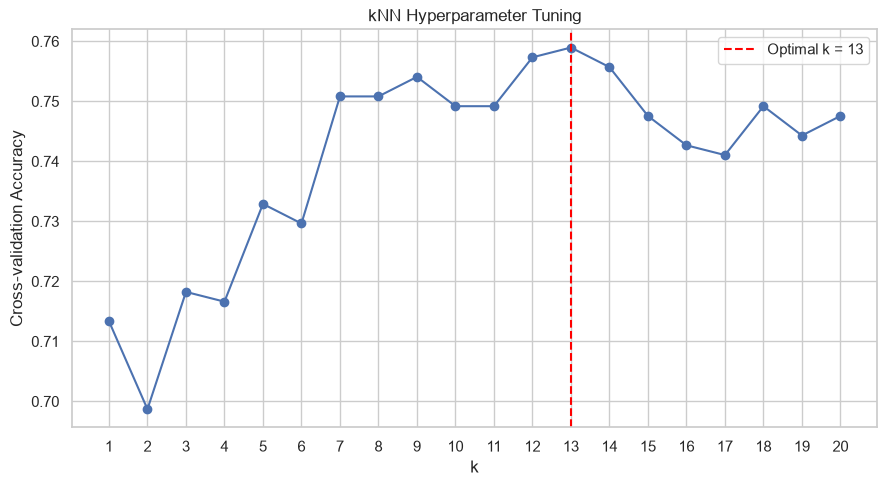

【kNN Tuned】


Accuracy : 0.7597
Precision: 0.6809
Recall   : 0.5926
F1       : 0.6337


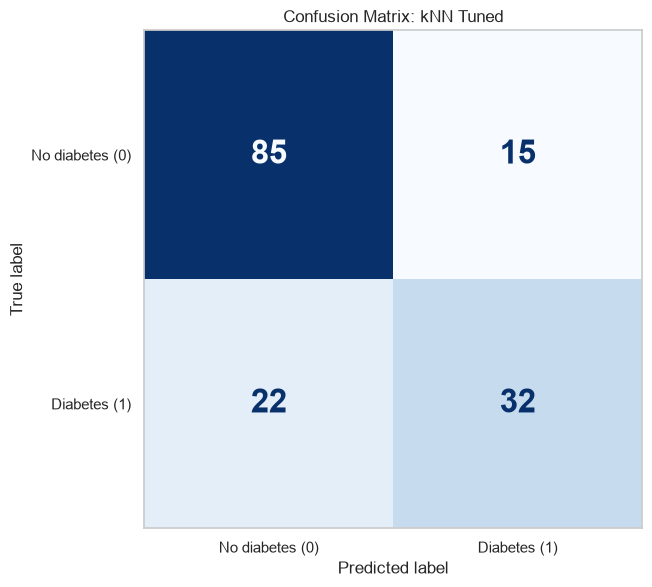

In [5]:
#* kを1から最大値まで変化させる
k_candidates = np.arange(1, max_number_of_k + 1)
knn_cv_accuracy = []
for k_value in k_candidates:
    model_in_validation = KNeighborsClassifier(
        n_neighbors=k_value,
        metric='euclidean'
    )

    #* 標準化済みトレインデータを5分割し、各サンプルのCV予測値を取得する
    predicted_y_in_cv = cross_val_predict(
        model_in_validation,
        autoscaled_x_train,
        y_train,
        cv=fold_number
    )
    accuracy_in_cv = accuracy_score(y_train, predicted_y_in_cv)
    print(f'k = {k_value:2d}, CV Accuracy = {accuracy_in_cv:.4f}')
    knn_cv_accuracy.append(accuracy_in_cv)

#* 交差検証Accuracyが最大となるkを選択して表示する
optimal_k = int(k_candidates[np.argmax(knn_cv_accuracy)])
print(f'交差検証で選択されたk: {optimal_k}')
print(f'交差検証の最良Accuracy: {max(knn_cv_accuracy):.4f}')

#* kと交差検証Accuracyの関係をグラフで確認する
plt.figure(figsize=(9, 5))
plt.plot(k_candidates, knn_cv_accuracy, marker='o')
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.xlabel('k')
plt.ylabel('Cross-validation Accuracy')
plt.title('kNN Hyperparameter Tuning')
plt.xticks(k_candidates)
plt.legend()
plt.tight_layout()
plt.show()

#* 選択したkを用いて、標準化済みトレーニングデータからkNNモデルを再構築する
knn_tuned = KNeighborsClassifier(n_neighbors=optimal_k, metric='euclidean')
knn_tuned.fit(autoscaled_x_train, y_train)

#* チューニング後のkNNモデルをテストデータで評価する
knn_tuned_scores, knn_tuned_pred, knn_tuned_prob = evaluate_model(
    knn_tuned, autoscaled_x_test, y_test, 'kNN Tuned'
)


【Random Forest Default】
Accuracy : 0.7727
Precision: 0.7111
Recall   : 0.5926
F1       : 0.6465


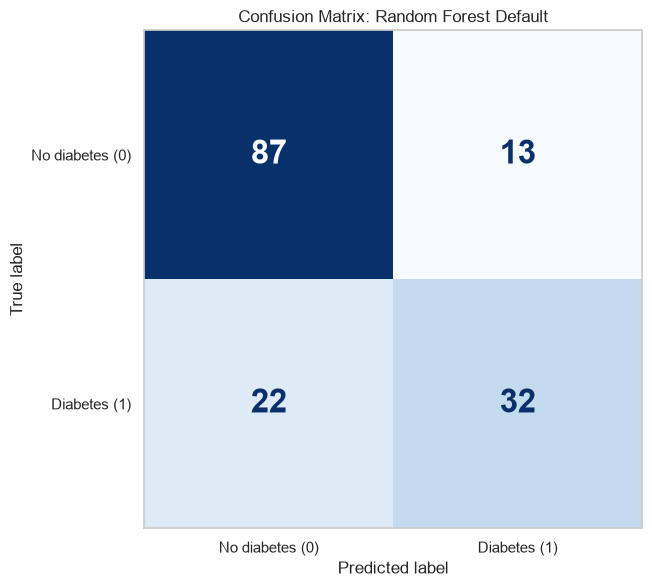

In [6]:
#* 分類に関するハイパーパラメータはデフォルトのRandom Forestモデルを構築する
rf_default = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_default.fit(x_train, y_train)

#* デフォルトRandom Forestモデルをテストデータで評価する
rf_default_scores, rf_default_pred, rf_default_prob = evaluate_model(
    rf_default, x_test, y_test, 'Random Forest Default'
)


OOBで選択された説明変数の割合: 0.6
各分岐で使用する説明変数の数: 5
最良OOB Accuracy: 0.7622


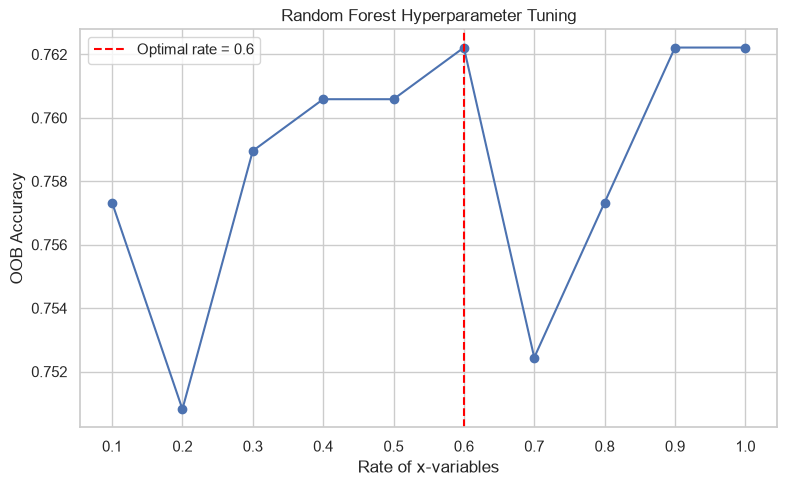

【Random Forest Tuned】
Accuracy : 0.7338
Precision: 0.6327
Recall   : 0.5741
F1       : 0.6019


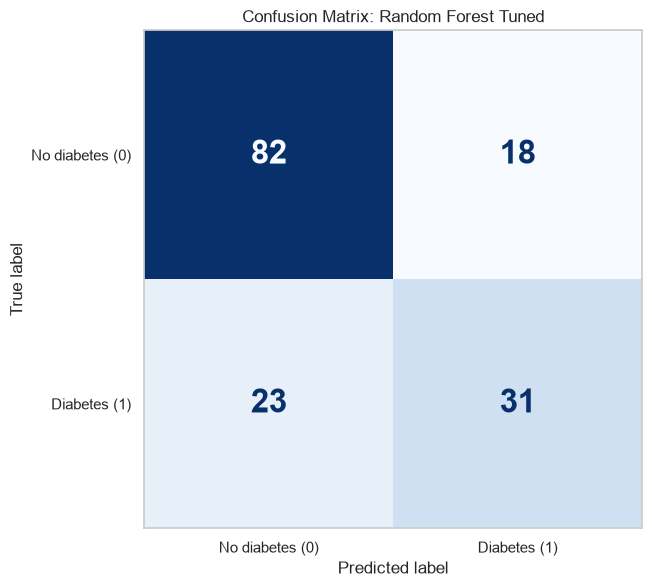

In [7]:
#* 説明変数の使用割合を0.1から1.0まで変化させ、各モデルのOOB Accuracyを計算する
accuracy_oob = []
number_of_features_candidates = []
for x_variables_rate in rf_x_variables_rates:
    number_of_features = int(max(math.ceil(x_train.shape[1] * x_variables_rate), 1))
    number_of_features_candidates.append(number_of_features)
    model_in_validation = RandomForestClassifier(
        n_estimators=rf_number_of_trees,
        max_features=number_of_features,
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model_in_validation.fit(x_train, y_train)
    accuracy_oob.append(model_in_validation.oob_score_)

#* OOB Accuracyが最大となる説明変数の割合と数を選択する
optimal_rf_index = int(np.argmax(accuracy_oob))
optimal_x_variables_rate = float(rf_x_variables_rates[optimal_rf_index])
optimal_number_of_features = number_of_features_candidates[optimal_rf_index]
print(f'OOBで選択された説明変数の割合: {optimal_x_variables_rate:.1f}')
print(f'各分岐で使用する説明変数の数: {optimal_number_of_features}')
print(f'最良OOB Accuracy: {max(accuracy_oob):.4f}')

#* 説明変数の割合とOOB Accuracyの関係をグラフで確認する
plt.figure(figsize=(8, 5))
plt.plot(rf_x_variables_rates, accuracy_oob, marker='o')
plt.axvline(
    optimal_x_variables_rate,
    color='red',
    linestyle='--',
    label=f'Optimal rate = {optimal_x_variables_rate:.1f}'
)
plt.xlabel('Rate of x-variables')
plt.ylabel('OOB Accuracy')
plt.title('Random Forest Hyperparameter Tuning')
plt.xticks(rf_x_variables_rates)
plt.legend()
plt.tight_layout()
plt.show()

#* 選択した説明変数数と300本の決定木を用いてRandom Forestモデルを再構築する
rf_tuned = RandomForestClassifier(
    n_estimators=rf_number_of_trees,
    max_features=optimal_number_of_features,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_tuned.fit(x_train, y_train)

#* チューニング後のRandom Forestモデルをテストデータで評価する
rf_tuned_scores, rf_tuned_pred, rf_tuned_prob = evaluate_model(
    rf_tuned, x_test, y_test, 'Random Forest Tuned'
)


最適なハイパーパラメータ: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}
最良CV Accuracy: 0.7785
【Random Forest RandomizedSearchCV】
Accuracy : 0.7662
Precision: 0.6875
Recall   : 0.6111
F1       : 0.6471


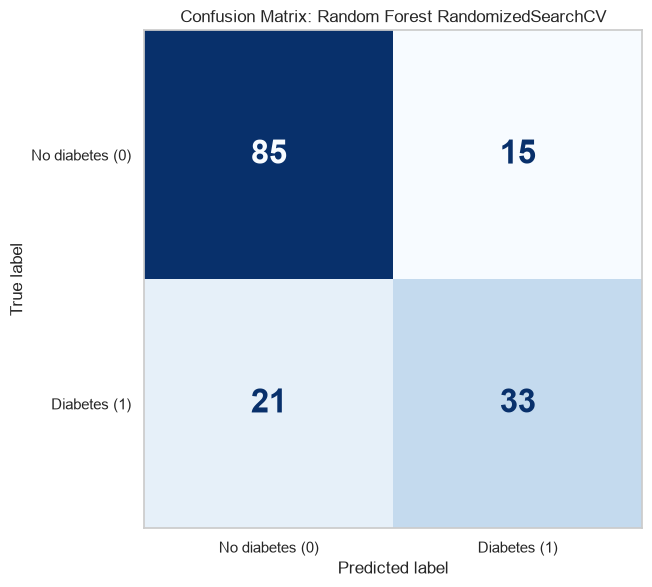

In [8]:
from sklearn.model_selection import RandomizedSearchCV

#* RandomizedSearchCVでRandom Forestのハイパーパラメータを調整する
rf_parameter_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', 0.5, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=rf_parameter_distributions,
    n_iter=30,
    scoring='accuracy',
    cv=fold_number,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)
rf_random_search.fit(x_train, y_train)

print('最適なハイパーパラメータ:', rf_random_search.best_params_)
print(f'最良CV Accuracy: {rf_random_search.best_score_:.4f}')

rf_randomized = rf_random_search.best_estimator_
rf_randomized_scores, rf_randomized_pred, rf_randomized_prob = evaluate_model(
    rf_randomized, x_test, y_test, 'Random Forest RandomizedSearchCV'
)


In [9]:
#* 5モデルのAccuracy・Precision・Recall・F1を表にまとめて比較する
comparison_df = pd.DataFrame([
    knn_default_scores,
    knn_tuned_scores,
    rf_default_scores,
    rf_tuned_scores,
    rf_randomized_scores
]).set_index('Model')
display(comparison_df.round(4))


,Accuracy,Precision,Recall,F1
Model,,,,
kNN Default,0.7013,0.5833,0.5185,0.5490
kNN Tuned,0.7597,0.6809,0.5926,0.6337
Random Forest Default,0.7727,0.7111,0.5926,0.6465
Random Forest Tuned,0.7338,0.6327,0.5741,0.6019
Random Forest RandomizedSearchCV,0.7662,0.6875,0.6111,0.6471


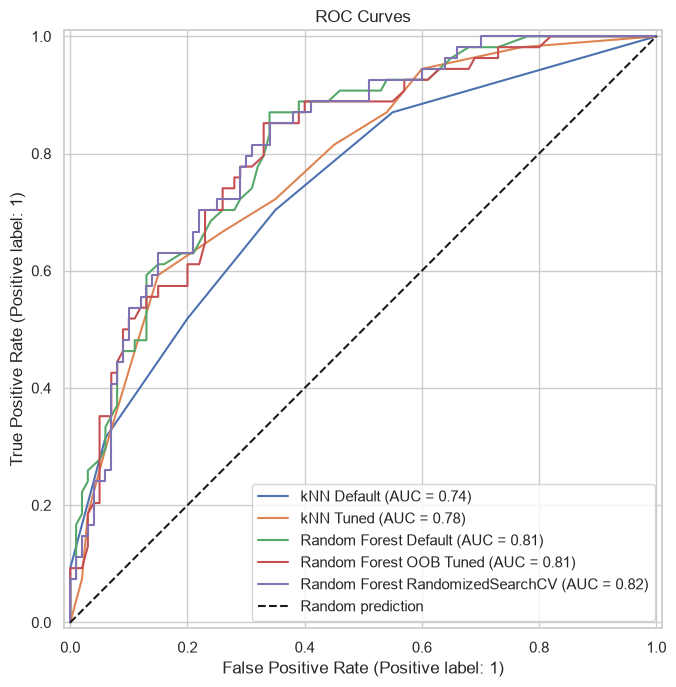

In [10]:
#* 5モデルの陽性クラスの予測確率をモデル名と対応させる
probabilities = {
    'kNN Default': knn_default_prob,
    'kNN Tuned': knn_tuned_prob,
    'Random Forest Default': rf_default_prob,
    'Random Forest OOB Tuned': rf_tuned_prob,
    'Random Forest RandomizedSearchCV': rf_randomized_prob
}

#* 5モデルのROC曲線を同じグラフに表示して比較する
fig, ax = plt.subplots(figsize=(8, 7))
for model_name, predicted_probability in probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test,
        predicted_probability,
        name=model_name,
        ax=ax
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random prediction')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


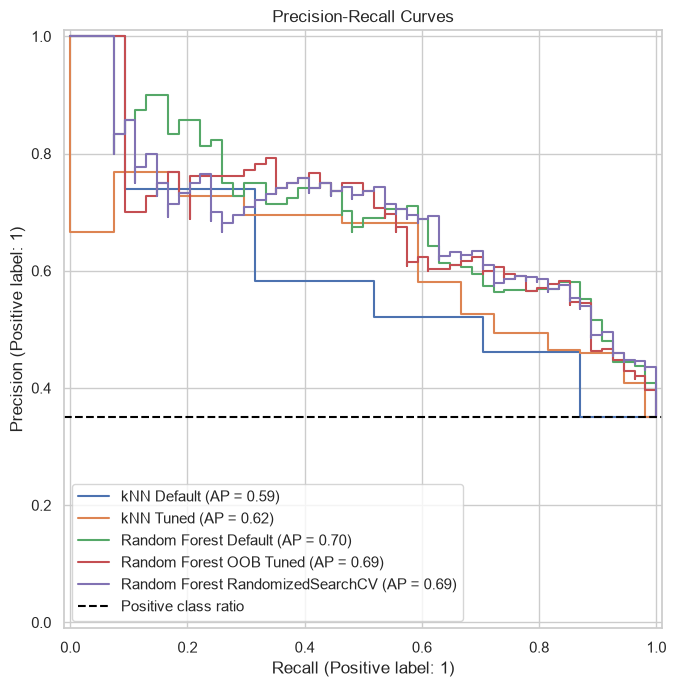

In [11]:
#* 5モデルのPrecision-Recall曲線を同じグラフに表示して比較する
fig, ax = plt.subplots(figsize=(8, 7))
for model_name, predicted_probability in probabilities.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        predicted_probability,
        name=model_name,
        ax=ax
    )
ax.axhline(y=y_test.mean(), color='black', linestyle='--', label='Positive class ratio')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()
